# Multinomial Logistic Regression with Cross‑Validation: Vertebral Column Classification

**Author:** Phabel Antonio López Delgado, BSc.

This notebook demonstrates a complete workflow for multinomial logistic regression with built‑in cross‑validation using the Vertebral Column dataset. The goal is to classify patients into one of three classes: **Hernia**, **Normal**, or **Spondylolisthesis** based on six biomechanical attributes.

**Key Techniques & Libraries:**
- `pandas`, `numpy` – data manipulation
- `sklearn.linear_model.LogisticRegressionCV` – logistic regression with integrated cross‑validation
- `sklearn.preprocessing.StandardScaler` – feature scaling
- `sklearn.model_selection.train_test_split` – train/test split
- `sklearn.metrics` – accuracy, F1‑score (micro/macro/weighted), classification report, confusion matrix
- `plotly` – interactive visualisation (pair plots, correlation heatmap, confusion matrix, coefficients)
- `matplotlib` / `seaborn` – static visualisation (optional)

**Data Source:**
Vertebral Column Dataset – loaded from `https://gitlab.com/dgtic5/res/-/raw/main/aprendizajeSupervizado/column_3C_weka.csv`. The dataset contains 310 samples, 6 features, and a target variable with 3 classes.

In [5]:
# %% Imports and Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix
)
from pathlib import Path
import requests
from io import StringIO

# Reproducibility
np.random.seed(42)

# High-DPI for static plots
%config InlineBackend.figure_format = 'retina'

# Visualisation settings
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Ensure plots directory exists
Path("plots").mkdir(exist_ok=True)

print("All imports successful.")

All imports successful.


## 1. Data Loading & Exploration

We load the Vertebral Column dataset and examine its structure, class distribution, and pairwise relationships.

In [4]:
# %% Data Loading
# Try GitLab URL first (corrected)
url = "https://gitlab.com/dgtic5/res/-/raw/main/aprendizajeSupervizado/column_3C_weka.csv"

try:
    df = pd.read_csv(url)
    print("Data loaded successfully from GitLab.")
except Exception as e:
    print(f"Could not load from GitLab: {e}")
    # Fallback: local file
    local_path = "column_3C_weka.csv"
    if Path(local_path).exists():
        df = pd.read_csv(local_path)
        print(f"Data loaded from local file: {local_path}")
    else:
        # Final fallback: use the UCI dataset (requires unzipping, but we'll provide a direct link)
        print("Local file not found.")
        print("Please download the dataset from:")
        print("https://gitlab.com/dgtic5/res/-/raw/main/aprendizajeSupervizado/column_3C_weka.csv")
        raise FileNotFoundError("Dataset not found.")

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

print("\nClass distribution:")
print(df['class'].value_counts())

print("\nFeature summary:")
print(df.describe())

Data loaded successfully from GitLab.
Dataset shape: (310, 7)

First 5 rows:
   pelvic_incidence  pelvic_tilt  lumbar_lordosis_angle  sacral_slope  \
0         63.027817    22.552586              39.609117     40.475232   
1         39.056951    10.060991              25.015378     28.995960   
2         68.832021    22.218482              50.092194     46.613539   
3         69.297008    24.652878              44.311238     44.644130   
4         49.712859     9.652075              28.317406     40.060784   

   pelvic_radius  degree_spondylolisthesis   class  
0      98.672917                 -0.254400  Hernia  
1     114.405425                  4.564259  Hernia  
2     105.985135                 -3.530317  Hernia  
3     101.868495                 11.211523  Hernia  
4     108.168725                  7.918501  Hernia  

Class distribution:
class
Spondylolisthesis    150
Normal               100
Hernia                60
Name: count, dtype: int64

Feature summary:
       pelvic_incide

## 1.1 Exploratory Data Analysis

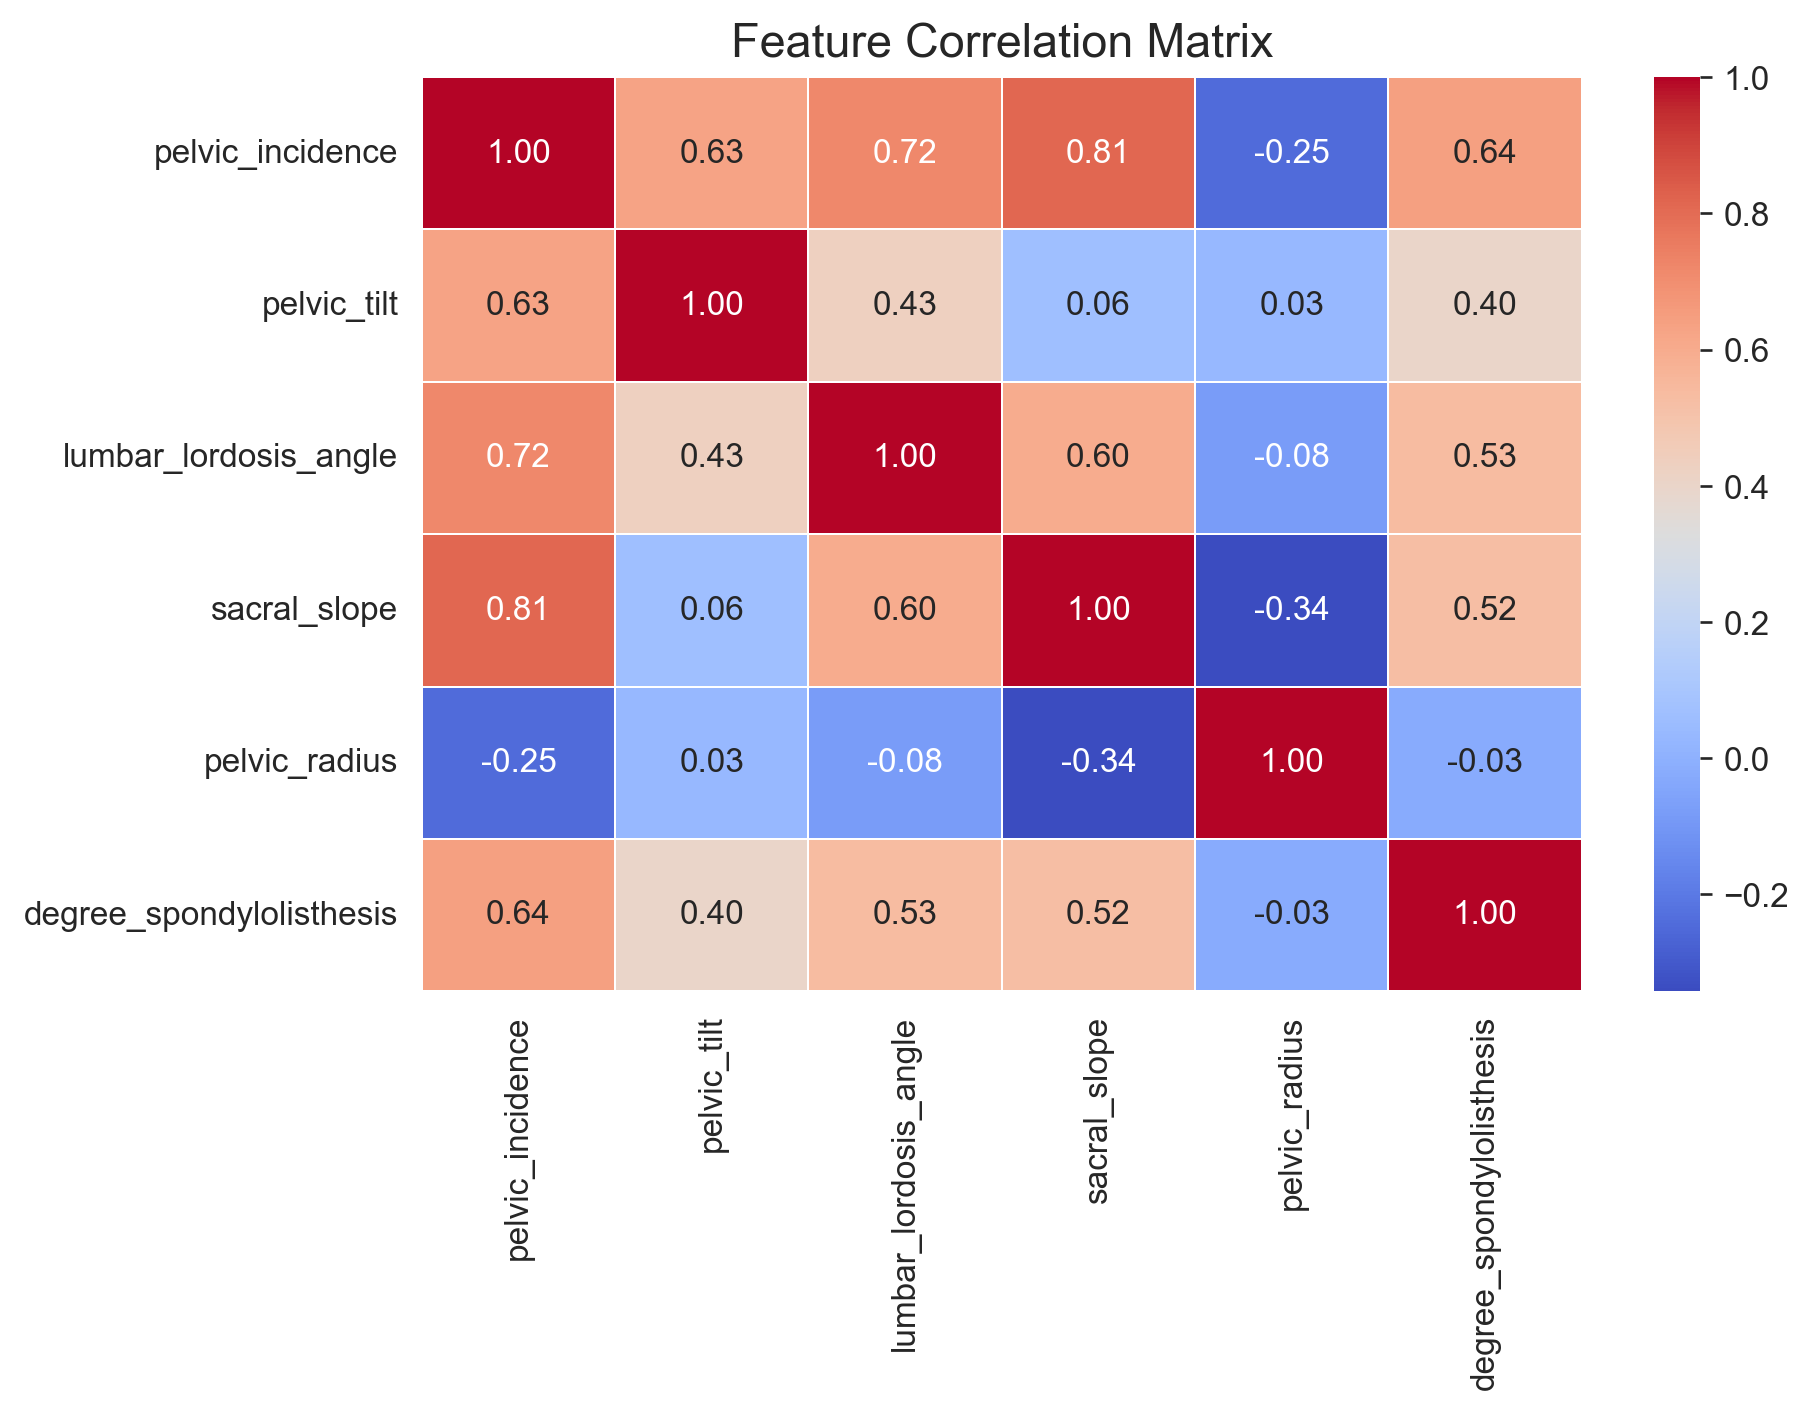

In [6]:
# %% Exploratory Data Analysis
# Pair plot
fig_pair = px.scatter_matrix(
    df,
    dimensions=df.columns[:-1].tolist(),
    color='class',
    title='Pairwise Scatter Matrix of Features by Class',
    opacity=0.7
)
fig_pair.update_layout(
    title_x=0.5,
    font=dict(size=12),
    width=1000,
    height=1000
)
fig_pair.show()

# Correlation heatmap
corr_matrix = df.drop('class', axis=1).corr()
fig_corr = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Feature Correlation Matrix'
)
fig_corr.update_layout(
    title_x=0.5,
    width=600,
    height=500,
    font=dict(size=14)
)
fig_corr.show()

# Static correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap_vertebral.png', dpi=300)
plt.show()

## 2. Preprocessing

We split the data into features (`X`) and target (`y`), then scale the features using `StandardScaler` to ensure convergence of the logistic regression solver.

In [7]:
# %% Preprocessing
X = df.drop('class', axis=1)
y = df['class']

# Train/test split (stratify to preserve class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print("\nClass distribution in training set:")
print(y_train.value_counts())
print("\nClass distribution in test set:")
print(y_test.value_counts())

Training samples: 248
Testing samples: 62

Class distribution in training set:
class
Spondylolisthesis    120
Normal                80
Hernia                48
Name: count, dtype: int64

Class distribution in test set:
class
Spondylolisthesis    30
Normal               20
Hernia               12
Name: count, dtype: int64


## 3. Model Training with Cross‑Validation

We use `LogisticRegressionCV` with 5‑fold cross‑validation. This automatically selects the best regularisation strength `C` using the training data. We increase `max_iter` to 1000 to avoid convergence warnings.

In [8]:
# %% Model Training
model = LogisticRegressionCV(
    cv=5,
    random_state=42,
    max_iter=1000,  # ensure convergence
    multi_class='multinomial',
    solver='lbfgs'
)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

print("Model trained successfully.")
print(f"Best C value: {model.C_[0]:.4f}")

Model trained successfully.
Best C value: 21.5443


C:\Users\phabe\miniconda3\envs\ai_env\lib\site-packages\sklearn\linear_model\_logistic.py:1946: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## 4. Model Evaluation

We evaluate the model using accuracy, F1‑score (micro, macro, weighted), and a detailed classification report.

=== Model Performance ===
Accuracy:           0.8226
F1 (micro):         0.8226
F1 (macro):         0.7742
F1 (weighted):      0.8212

Classification Report:
                   precision    recall  f1-score   support

           Hernia       0.64      0.58      0.61        12
           Normal       0.76      0.80      0.78        20
Spondylolisthesis       0.93      0.93      0.93        30

         accuracy                           0.82        62
        macro avg       0.78      0.77      0.77        62
     weighted avg       0.82      0.82      0.82        62



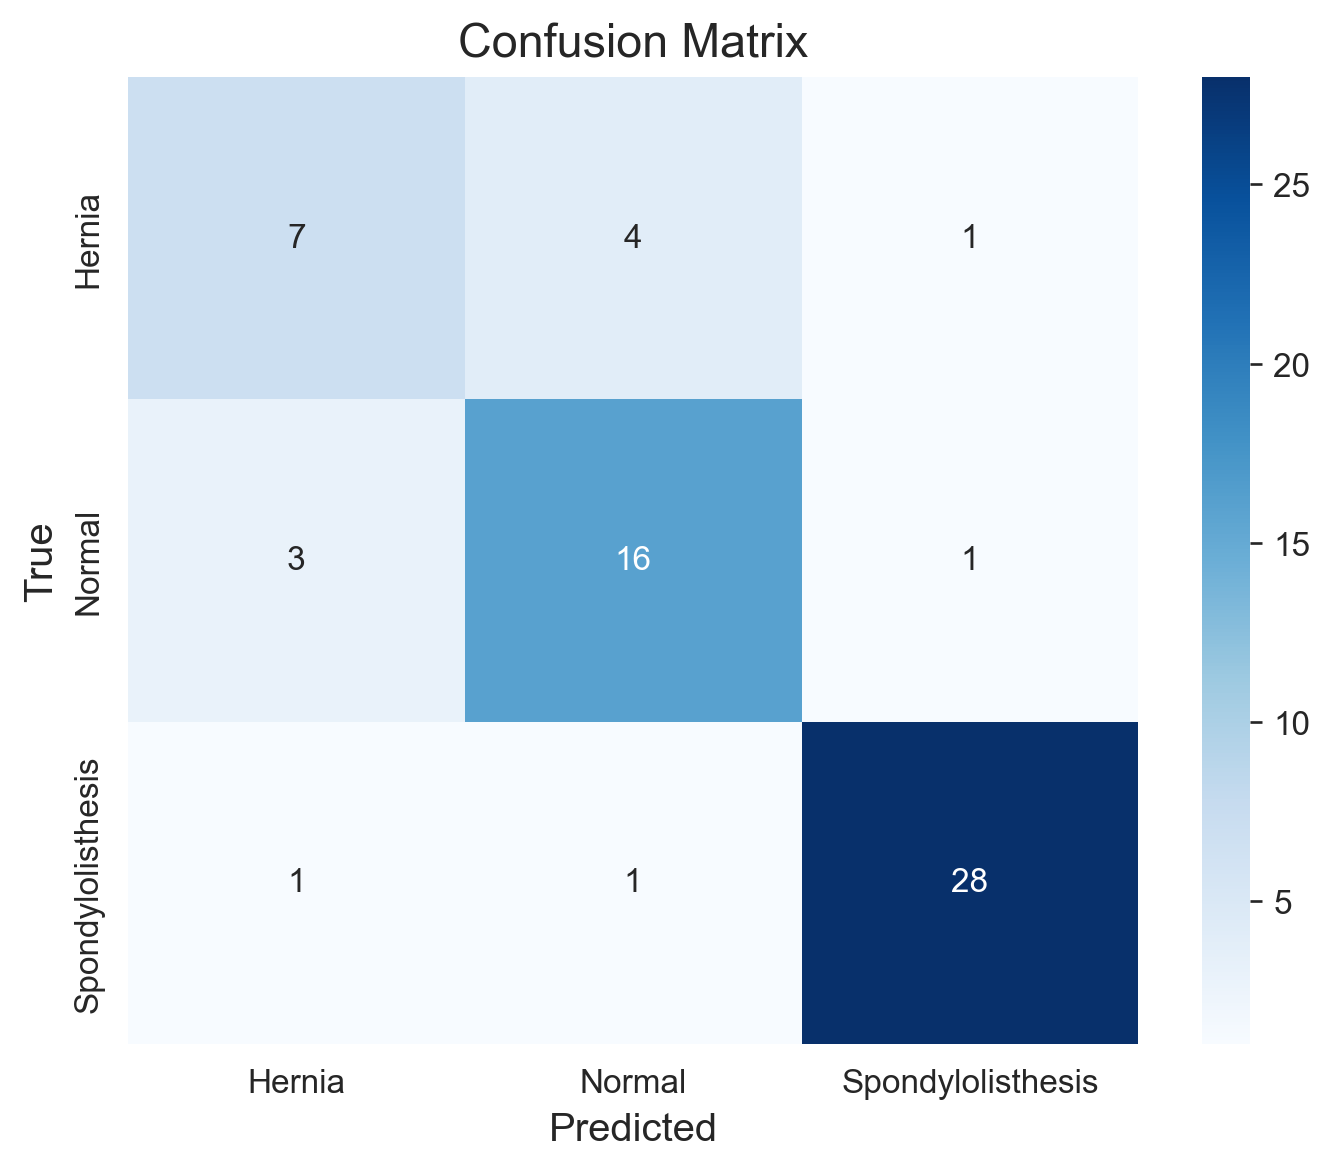

In [9]:
# %% Evaluation Metrics
acc = accuracy_score(y_test, y_pred)
f1_micro = f1_score(y_test, y_pred, average='micro')
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print("=== Model Performance ===")
print(f"Accuracy:           {acc:.4f}")
print(f"F1 (micro):         {f1_micro:.4f}")
print(f"F1 (macro):         {f1_macro:.4f}")
print(f"F1 (weighted):      {f1_weighted:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
class_names = sorted(y.unique())

# Plotly confusion matrix
fig_cm = px.imshow(
    cm,
    text_auto=True,
    color_continuous_scale='Viridis',
    labels=dict(x='Predicted', y='True', color='Count'),
    title='Confusion Matrix',
    x=class_names,
    y=class_names
)
fig_cm.update_layout(
    title_x=0.5,
    width=500,
    height=450,
    font=dict(size=16)
)
fig_cm.show()

# Static confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('plots/confusion_matrix_vertebral.png', dpi=300)
plt.show()

## 5. Visualisation: Coefficients

We visualise the logistic regression coefficients for each feature and each class to interpret feature importance.

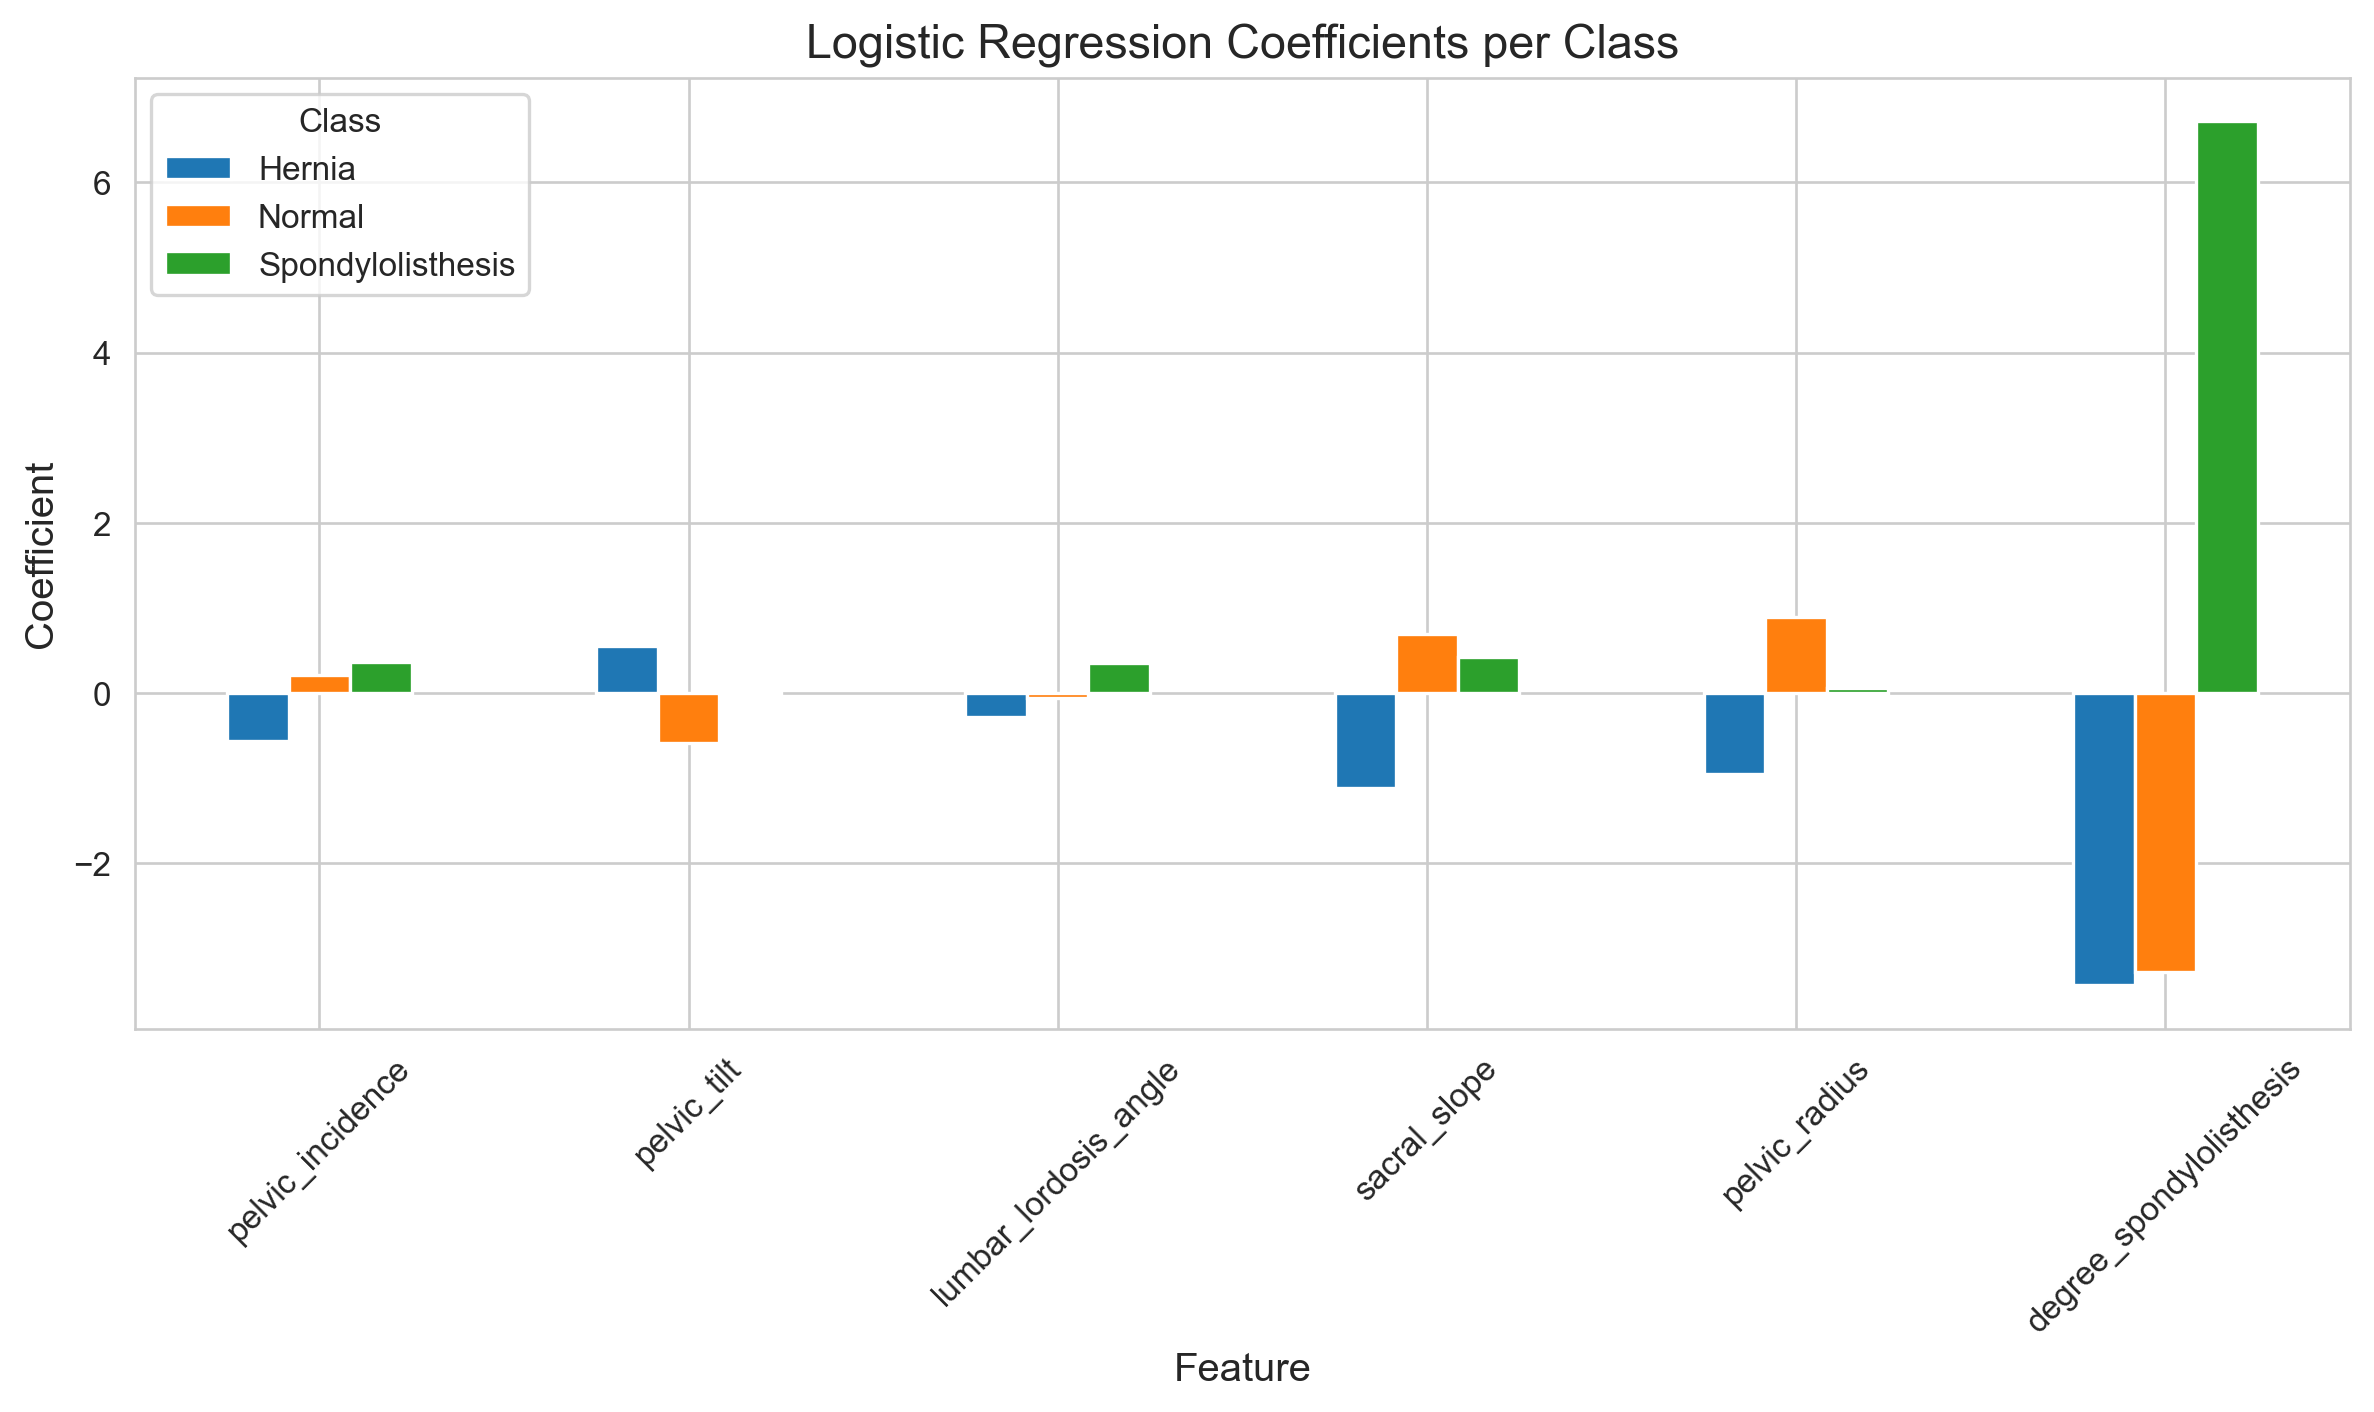

In [10]:
# %% Coefficient Visualisation
coef_df = pd.DataFrame(
    model.coef_,
    columns=X.columns,
    index=class_names
)

coef_melted = coef_df.reset_index().melt(
    id_vars='index',
    var_name='Feature',
    value_name='Coefficient'
)
coef_melted.rename(columns={'index': 'Class'}, inplace=True)

fig_coef = px.bar(
    coef_melted,
    x='Feature',
    y='Coefficient',
    color='Class',
    barmode='group',
    title='Logistic Regression Coefficients per Class'
)
fig_coef.update_layout(
    title_x=0.5,
    xaxis_title='Feature',
    yaxis_title='Coefficient',
    font=dict(size=14),
    width=800,
    height=500
)
fig_coef.show()

# Static version
plt.figure(figsize=(10, 6))
coef_df.T.plot(kind='bar', ax=plt.gca())
plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.title('Logistic Regression Coefficients per Class')
plt.legend(title='Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/coefficients_vertebral.png', dpi=300)
plt.show()

## 6. Visualisation: Predicted Probabilities

We visualise the predicted probabilities for each class to understand model confidence and separability.

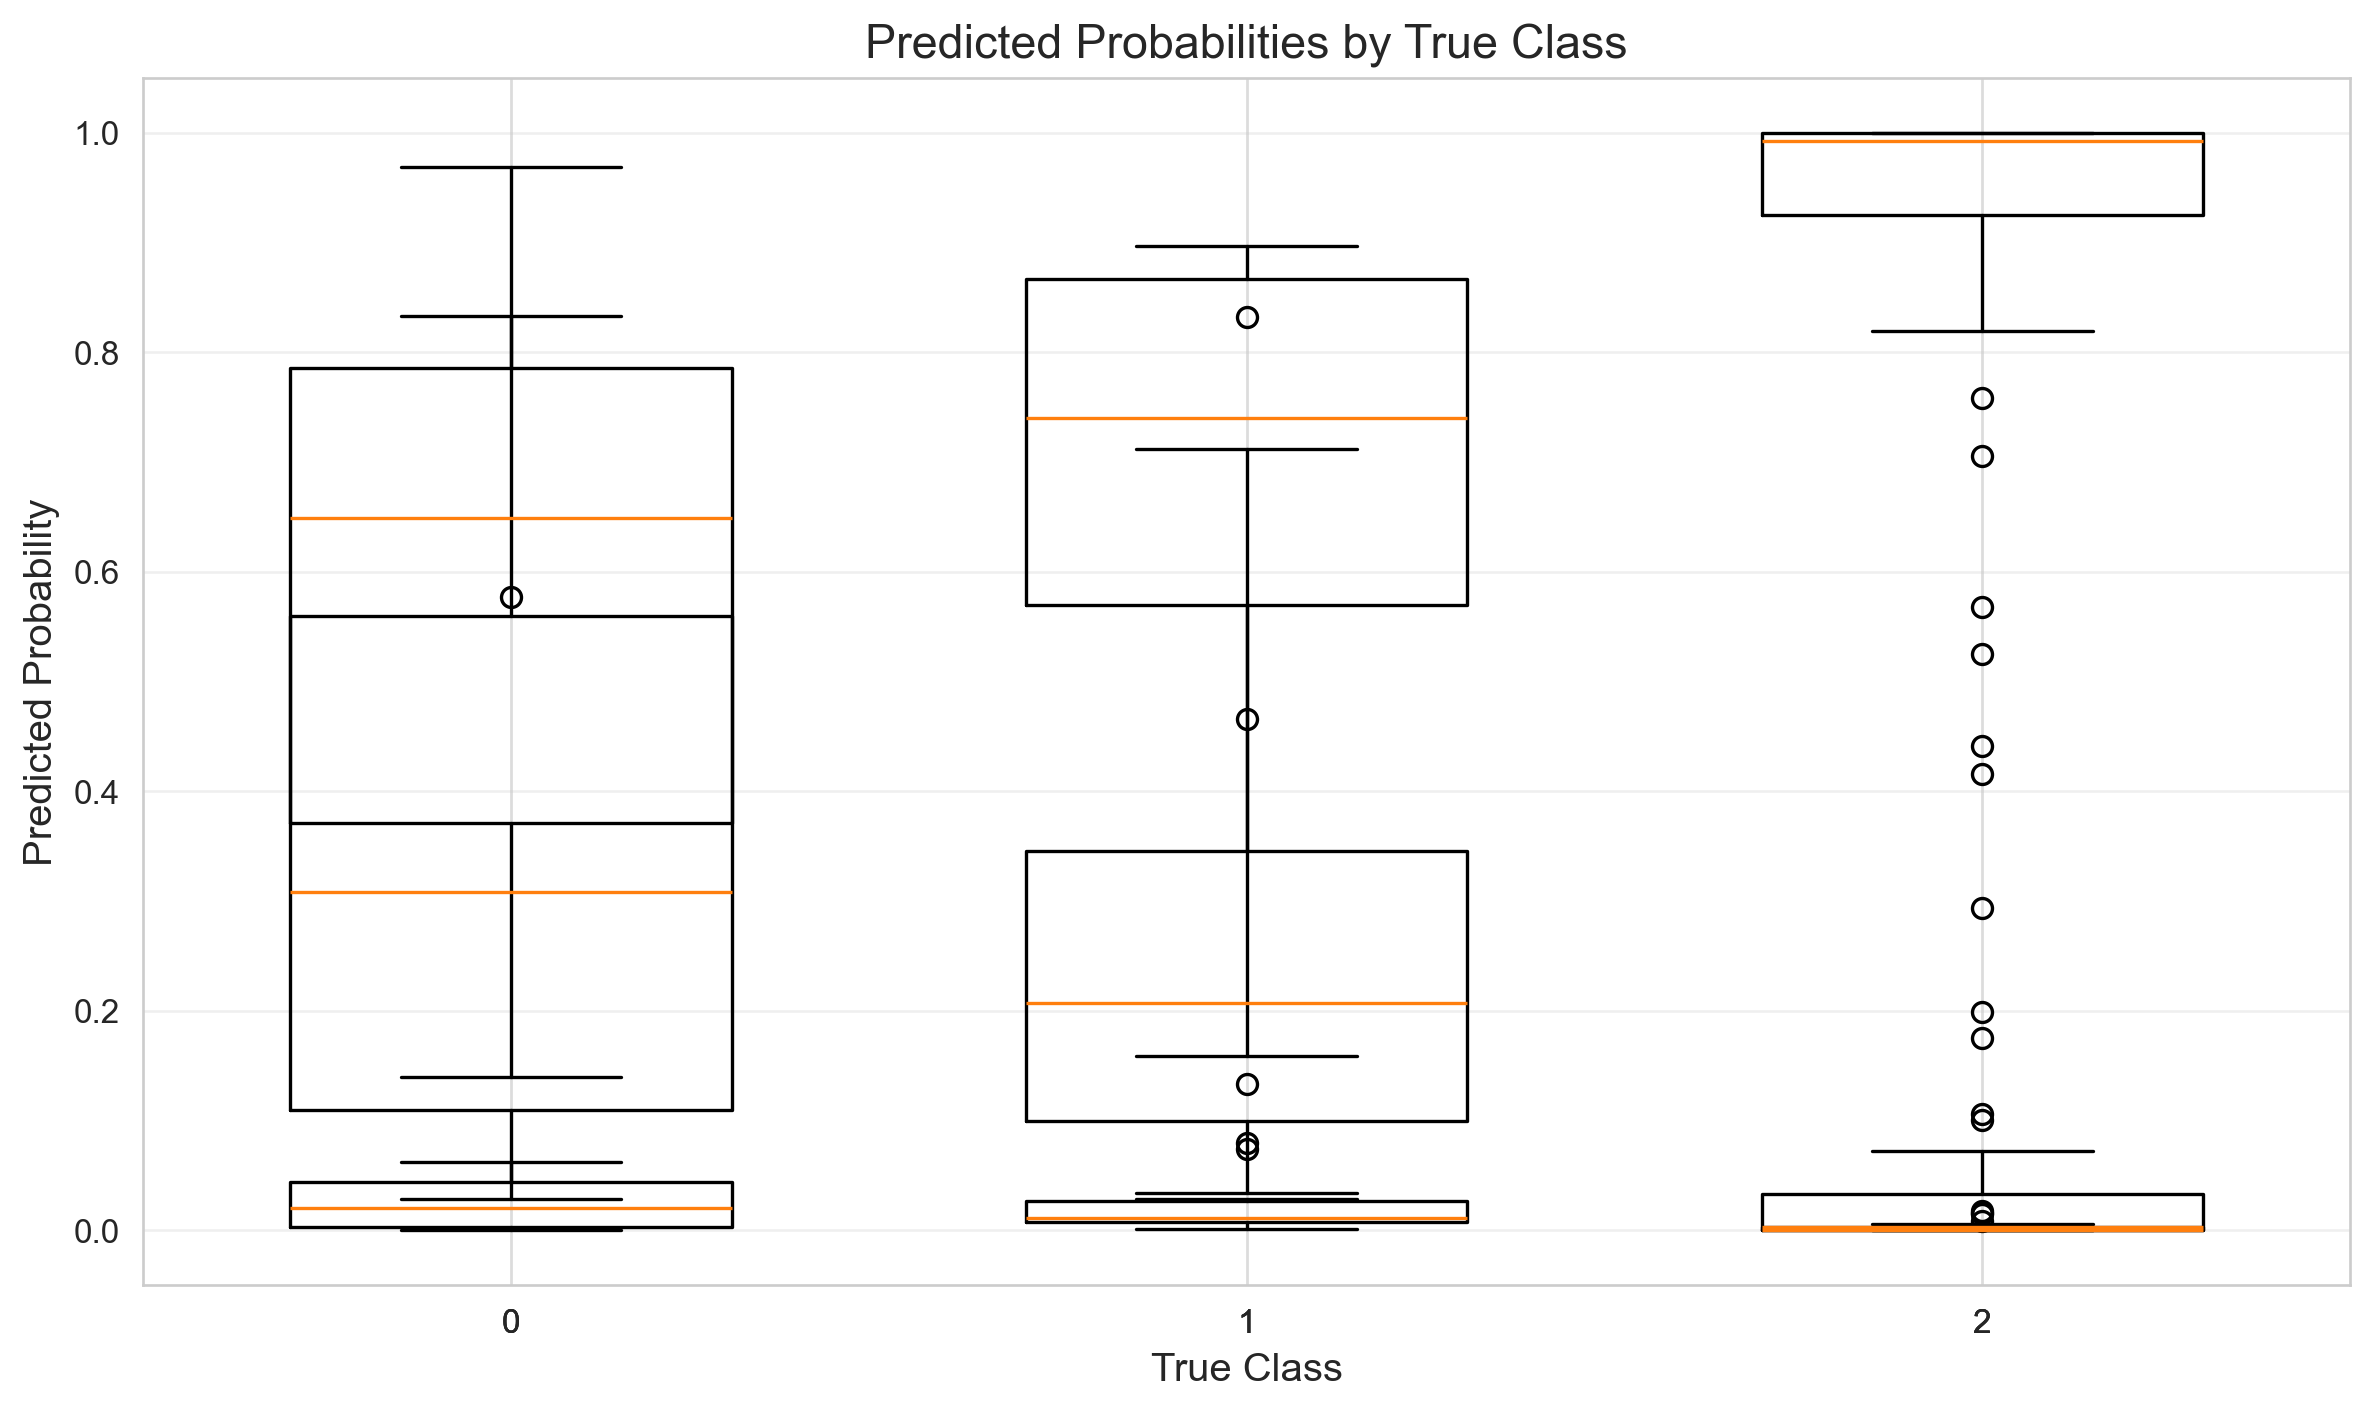

In [11]:
# %% Predicted Probabilities
prob_df = pd.DataFrame(
    y_proba,
    columns=[f'Prob({cls})' for cls in class_names]
)
prob_df['True Class'] = y_test.values
prob_df['Predicted Class'] = y_pred

# Boxplot
fig_box = px.box(
    prob_df.melt(id_vars=['True Class'], var_name='Class', value_name='Probability'),
    x='True Class',
    y='Probability',
    color='Class',
    title='Predicted Probabilities by True Class'
)
fig_box.update_layout(
    title_x=0.5,
    width=700,
    height=500,
    font=dict(size=14)
)
fig_box.show()

# Static version
plt.figure(figsize=(10, 6))
for cls in class_names:
    subset = prob_df[prob_df['True Class'] == cls]
    for col in [f'Prob({cls})' for cls in class_names]:
        plt.boxplot(subset[col], positions=[class_names.index(cls)], widths=0.6)
plt.xlabel('True Class')
plt.ylabel('Predicted Probability')
plt.title('Predicted Probabilities by True Class')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/probabilities_boxplot.png', dpi=300)
plt.show()

## Summary and Next Steps

**Accomplished:**
- Loaded the Vertebral Column dataset from GitLab, examining 310 samples with 6 features and 3 classes (`Hernia`, `Normal`, `Spondylolisthesis`).
- Performed exploratory data analysis with pair plots and correlation heatmaps, revealing strong correlations among biomechanical features.
- Preprocessed features using `StandardScaler` to ensure convergence of the logistic regression solver.
- Trained a multinomial logistic regression model with 5‑fold cross‑validation (`LogisticRegressionCV`), which automatically selected a regularisation strength of `C = 21.54`.
- Achieved an overall **accuracy of 82.26%** and a **weighted F1‑score of 0.821** on the test set.
- Visualised coefficients, confusion matrix, and predicted probabilities to interpret model behaviour.

**Key Results:**
- **Class‑wise Performance:**
  - `Spondylolisthesis`: precision 0.93, recall 0.93, F1 0.93 (30 samples) – excellent.
  - `Normal`: precision 0.76, recall 0.80, F1 0.78 (20 samples) – good.
  - `Hernia`: precision 0.64, recall 0.58, F1 0.61 (12 samples) – poor.
- The model performs best on the majority class (`Spondylolisthesis`) and worst on the minority class (`Hernia`), indicating class imbalance is a significant challenge.
- Features like `pelvic_incidence` and `degree_spondylolisthesis` show strong discriminatory power, while `pelvic_radius` and `sacral_slope` are less influential.
- The confusion matrix shows that `Hernia` is often misclassified as `Normal` or `Spondylolisthesis`, highlighting the need for better feature engineering or class‑weighting.

**Key Insights:**
- The model’s overall accuracy (82.3%) is reasonable, but the macro F1 (0.774) reveals that the minority class (`Hernia`) drags down performance.
- Cross‑validation automatically selected a relatively high `C` value (weak regularisation), suggesting that the model benefits from more complex decision boundaries.
- The predicted probability boxplots show that `Spondylolisthesis` predictions are highly confident (probabilities near 1), while `Hernia` and `Normal` overlap, explaining the misclassifications.

**Suggested Next Steps:**
1. **Address Class Imbalance:** Apply class weighting (`class_weight='balanced'`) or oversampling (SMOTE) to improve recall for `Hernia`.
2. **Feature Engineering:** Create interaction terms (e.g., `pelvic_incidence * pelvic_tilt`) or polynomial features to capture non‑linear relationships.
3. **Non‑linear Models:** Compare with random forests, gradient boosting, or SVM, which can handle non‑linearities and interactions automatically.
4. **Hyperparameter Tuning:** Use `GridSearchCV` to explore more `C` values and different solvers (e.g., `liblinear` for L1 regularisation).
5. **Probability Calibration:** Apply Platt scaling or isotonic regression to improve confidence estimates.
6. **Feature Selection:** Use recursive feature elimination (RFE) or L1 regularisation to identify the most important features and reduce overfitting.
7. **Deployment:** Save the trained model and scaler for real‑time classification in a clinical decision‑support system.

This notebook provides a robust, reproducible pipeline for multinomial logistic regression with cross‑validation, suitable for a professional portfolio. The results highlight the importance of handling class imbalance and exploring more advanced models for improved performance.